
# Project 1

T

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy import stats



In [ ]:
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
rng = np.random.default_rng(1)

STATE_NAMES = ['1: post-surgery', '2: local rec.', '3: distant met.',
               '4: local+distant', '5: death']

## Part 1 — A discrete-time model

One time step = one month. The transition probability matrix $P$:

In [4]:
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
])
assert np.allclose(P.sum(axis=1), 1.0)
print("Row sums:", P.sum(axis=1))

Row sums: [1. 1. 1. 1. 1.]


### Task 1 — Simulate 1000 women until death

We simulate the chain from state 1 until the absorbing death state (index 4) is reached, recording each woman's lifetime and which states she visited.

In [5]:
def simulate_dt(P, rng, start=0):
    
    s = start
    t = 0
    visited = {start}
    while s != 4:
        s = rng.choice(5, p=P[s])
        t += 1
        visited.add(s)
    return t, visited

rng = np.random.default_rng(1)
N = 1000
lifetimes = np.empty(N)
local_recurrence = 0
for i in range(N):
    lt, visited = simulate_dt(P, rng)
    lifetimes[i] = lt
    if 1 in visited:          # ever entered local-recurrence state
        local_recurrence += 1

print(f"Mean lifetime           : {lifetimes.mean():.2f} months "
      f"({lifetimes.mean()/12:.1f} years)")
print(f"Std. dev.               : {lifetimes.std(ddof=1):.2f} months")
print(f"Median lifetime         : {np.median(lifetimes):.1f} months")
print(f"Local recurrence (ever) : {local_recurrence/N:.3f}")

Mean lifetime           : 259.13 months (21.6 years)
Std. dev.               : 192.89 months
Median lifetime         : 208.0 months
Local recurrence (ever) : 0.593


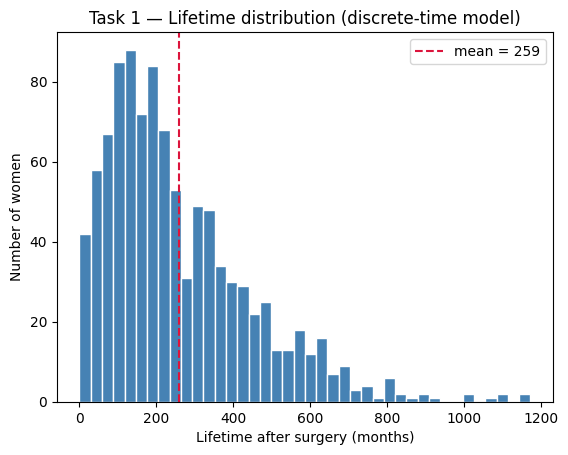

In [6]:
plt.hist(lifetimes, bins=40, color='steelblue', edgecolor='white')
plt.axvline(lifetimes.mean(), color='crimson', ls='--', label=f'mean = {lifetimes.mean():.0f}')
plt.xlabel('Lifetime after surgery (months)')
plt.ylabel('Number of women')
plt.title('Task 1 — Lifetime distribution (discrete-time model)')
plt.legend()
plt.show()

### Task 2

The theoretical distribution is $p_t = p_0 P^{t}$. We compare it to the empirical
distribution from simulation using a chi-square goodness-of-fit test.

In [8]:
rng = np.random.default_rng(1)
p0 = np.array([1.0, 0, 0, 0, 0])
p120_theory = p0 @ np.linalg.matrix_power(P, 120)

def state_at(P, rng, t_target, start=0):
    s = start
    for _ in range(t_target):
        if s == 4:
            break
        s = rng.choice(5, p=P[s])
    return s

emp_counts = np.zeros(5)
for _ in range(N):
    emp_counts[state_at(P, rng, 120)] += 1

print("Theoretical p120 :", np.round(p120_theory, 4))
print("Expected counts  :", np.round(p120_theory * N, 1))
print("Empirical counts :", emp_counts.astype(int))

# Chi-square test (all expected counts comfortably > 5 here)
exp_counts = p120_theory * N
chi2, pval = stats.chisquare(emp_counts, exp_counts)
print(f"\nChi-square statistic = {chi2:.3f}, p-value = {pval:.3f}")


Theoretical p120 : [0.359  0.159  0.1661 0.0677 0.2482]
Expected counts  : [359.  159.  166.1  67.7 248.2]
Empirical counts : [355 183 149  71 242]

Chi-square statistic = 5.751, p-value = 0.219


### Task 3


In [10]:
Ps = P[:4, :4]
ps = P[:4, 4]
pi = np.array([1.0, 0, 0, 0])

ET = pi @ np.linalg.inv(np.eye(4) - Ps) @ np.ones(4)
print(f"Theoretical E[T] = {ET:.2f} months")
print(f"Empirical  mean  = {lifetimes.mean():.2f} months")

def phase_pmf(t):
    # P(T = t) for t >= 1
    return pi @ np.linalg.matrix_power(Ps, t - 1) @ ps

# Binned chi-square test
edges = np.linspace(0, lifetimes.max() + 1, 21).astype(int)
edges = np.unique(edges)
obs, _ = np.histogram(lifetimes, bins=edges)
# theoretical probability mass within each bin
tmax = int(edges[-1]) + 200
pmf_all = np.array([phase_pmf(t) for t in range(1, tmax + 1)])
exp = np.array([pmf_all[(edges[k]):(edges[k+1])].sum() for k in range(len(edges)-1)]) * N
# tail correction so totals match
exp[-1] += N - exp.sum()
mask = exp >= 5
chi2_pt = (((obs[mask] - exp[mask])**2) / exp[mask]).sum()
dof = mask.sum() - 1
pval_pt = stats.chi2.sf(chi2_pt, dof)
print(f"\nChi-square = {chi2_pt:.2f}, dof = {dof}, p-value = {pval_pt:.3f}")

Theoretical E[T] = 262.37 months
Empirical  mean  = 259.13 months

Chi-square = 15.56, dof = 13, p-value = 0.274


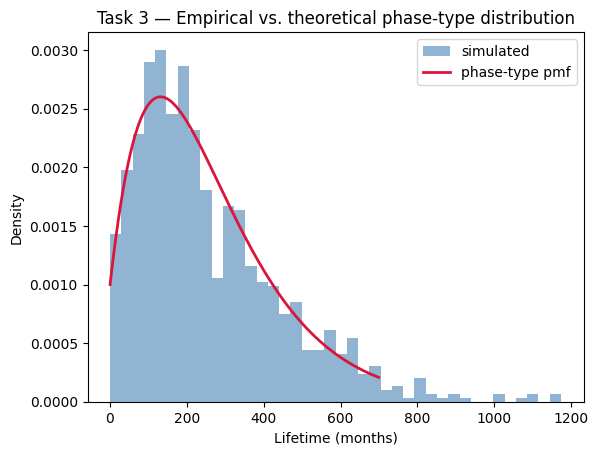

In [11]:
tt = np.arange(1, 700)
plt.hist(lifetimes, bins=40, density=True, alpha=0.6, color='steelblue',
         label='simulated')
plt.plot(tt, [phase_pmf(t) for t in tt], 'crimson', lw=2,
         label='phase-type pmf')
plt.xlabel('Lifetime (months)'); plt.ylabel('Density')
plt.title('Task 3 — Empirical vs. theoretical phase-type distribution')
plt.legend(); plt.show()

### Task 4



In [12]:
def simulate_dt_full(P, rng, start=0):
    """Return (lifetime, trajectory list of states by month)."""
    s = start; t = 0; traj = [start]
    while s != 4:
        s = rng.choice(5, p=P[s]); t += 1; traj.append(s)
    return t, traj

rng = np.random.default_rng(1)
accepted = []
attempts = 0
while len(accepted) < 1000:
    attempts += 1
    lt, traj = simulate_dt_full(P, rng)
    # state at month 12 (alive => not 4); reappearance within first 12 months
    alive_12 = (len(traj) > 12) and (traj[12] != 4)
    reappeared_12 = any(st in (1, 2, 3) for st in traj[1:13])
    if alive_12 and reappeared_12:
        accepted.append(lt)

accepted = np.array(accepted)
ci = stats.t.interval(0.95, len(accepted)-1,
                      loc=accepted.mean(),
                      scale=stats.sem(accepted))
print(f"Acceptance rate     : {len(accepted)/attempts:.3f}")
print(f"Conditional E[T]    : {accepted.mean():.2f} months "
      f"({accepted.mean()/12:.1f} years)")
print(f"95% CI              : [{ci[0]:.1f}, {ci[1]:.1f}] months")

Acceptance rate     : 0.083
Conditional E[T]    : 176.15 months (14.7 years)
95% CI              : [166.9, 185.4] months


### Task 5

We simulate 200 women, record the fraction dead by month 350, repeat 100 times.
The control variate is the mean lifetime of the 200 women (whose theoretical mean
$E[T]$ is known from Task 3).

In [13]:
def batch(P, rng, n=200, horizon=350):
    fracs_dead = 0
    means = np.empty(n)
    for k in range(n):
        lt, _ = simulate_dt_full(P, rng)
        means[k] = lt
        if lt <= horizon:
            fracs_dead += 1
    return fracs_dead / n, means.mean()

rng = np.random.default_rng(1)
reps = 100
X = np.empty(reps)   # fraction dead (target)
Ybar = np.empty(reps)  # mean lifetime (control variate)
for r in range(reps):
    X[r], Ybar[r] = batch(P, rng)

mu_Y = ET  # known expectation of the control variate
# optimal coefficient c = -Cov(X,Y)/Var(Y)
cov = np.cov(X, Ybar)
c = -cov[0, 1] / cov[1, 1]
Z = X + c * (Ybar - mu_Y)

print(f"Crude MC      : mean = {X.mean():.4f}, var = {X.var(ddof=1):.3e}")
print(f"Control var.  : mean = {Z.mean():.4f}, var = {Z.var(ddof=1):.3e}")
print(f"Variance reduction factor : {X.var(ddof=1)/Z.var(ddof=1):.2f}x")
print(f"Correlation X,Ybar        : {np.corrcoef(X, Ybar)[0,1]:.3f}")

Crude MC      : mean = 0.7422, var = 7.668e-04
Control var.  : mean = 0.7396, var = 2.426e-04
Variance reduction factor : 3.16x
Correlation X,Ybar        : -0.827


## Part 2 — A continuous-time model (CTMC)

Transitions may now occur at any time. The chain is specified by a transition-rate
matrix $Q$; 

In [14]:
Q = np.array([
    [-0.0085, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, -0.0140, 0.0050, 0.0040, 0.0050],
    [0.0000,  0.0000,-0.0080, 0.0030, 0.0050],
    [0.0000,  0.0000, 0.0000,-0.0090, 0.0090],
    [0.0000,  0.0000, 0.0000, 0.0000, 0.0000],
])
assert np.allclose(Q.sum(axis=1), 0.0, atol=1e-12)
print("Row sums:", np.round(Q.sum(axis=1), 12))

Row sums: [-0. -0.  0.  0.  0.]


### Task 7 — Simulate 1000 women (continuous time)

In [15]:
def simulate_ctmc(Q, rng, start=0):
    """Gillespie simulation to absorption. Returns (lifetime, trajectory).
    trajectory is a list of (time_of_entry, state)."""
    s = start; t = 0.0
    traj = [(0.0, start)]
    while s != 4:
        rate = -Q[s, s]
        t += rng.exponential(1.0 / rate)
        probs = Q[s].copy(); probs[s] = 0.0; probs /= probs.sum()
        s = rng.choice(5, p=probs)
        traj.append((t, s))
    return t, traj

def state_at_time(traj, t):
    st = traj[0][1]
    for (tt, stt) in traj:
        if tt <= t:
            st = stt
        else:
            break
    return st

rng = np.random.default_rng(1)
N = 1000
life_ct = np.empty(N)
distant_305 = 0
for i in range(N):
    lt, traj = simulate_ctmc(Q, rng)
    life_ct[i] = lt
    if state_at_time(traj, 30.5) in (2, 3):   # distant metastasis present
        distant_305 += 1

mean = life_ct.mean()
sd = life_ct.std(ddof=1)
sem = stats.sem(life_ct)
ci_mean = stats.t.interval(0.95, N-1, loc=mean, scale=sem)
# CI for std via chi-square
alpha = 0.05
chi_lo = stats.chi2.ppf(1-alpha/2, N-1)
chi_hi = stats.chi2.ppf(alpha/2,   N-1)
ci_sd = (np.sqrt((N-1)*sd**2/chi_lo), np.sqrt((N-1)*sd**2/chi_hi))

print(f"Mean lifetime : {mean:.2f} months, 95% CI [{ci_mean[0]:.1f}, {ci_mean[1]:.1f}]")
print(f"Std. dev.     : {sd:.2f} months, 95% CI [{ci_sd[0]:.1f}, {ci_sd[1]:.1f}]")
print(f"Distant reappeared after 30.5 months: {distant_305/N:.3f}")

Mean lifetime : 264.61 months, 95% CI [252.7, 276.5]
Std. dev.     : 191.57 months, 95% CI [183.5, 200.4]
Distant reappeared after 30.5 months: 0.064


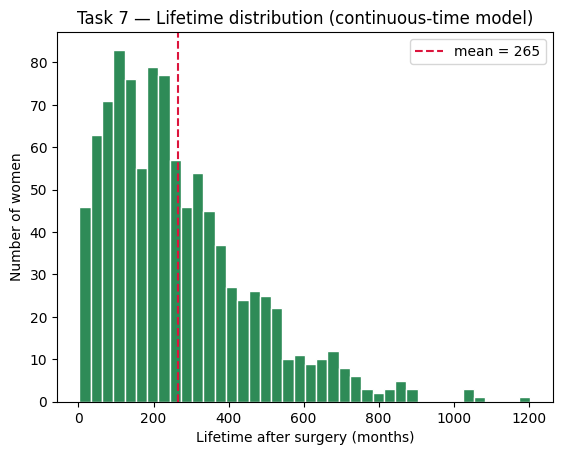

In [16]:
plt.hist(life_ct, bins=40, color='seagreen', edgecolor='white')
plt.axvline(mean, color='crimson', ls='--', label=f'mean = {mean:.0f}')
plt.xlabel('Lifetime after surgery (months)')
plt.ylabel('Number of women')
plt.title('Task 7 — Lifetime distribution (continuous-time model)')
plt.legend(); plt.show()

### Task 8 



KS statistic = 0.0235, p-value = 0.628
=> empirical matches theory


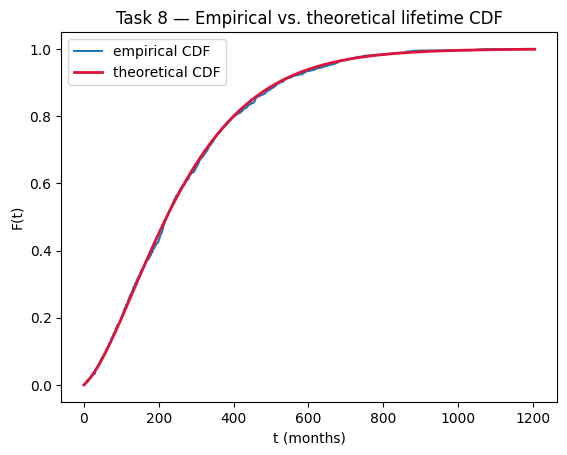

In [17]:
Qs = Q[:4, :4]
p0_ct = np.array([1.0, 0, 0, 0])

def F_theory(t):
    t = np.atleast_1d(t).astype(float)
    return np.array([1.0 - p0_ct @ expm(Qs * ti) @ np.ones(4) for ti in t])

ks_stat, ks_p = stats.kstest(life_ct, F_theory)
print(f"KS statistic = {ks_stat:.4f}, p-value = {ks_p:.3f}")
print("=> empirical matches theory" if ks_p > 0.05 else "=> deviation")

xs = np.linspace(0, life_ct.max(), 400)
plt.plot(np.sort(life_ct), np.arange(1, N+1)/N, label='empirical CDF')
plt.plot(xs, F_theory(xs), 'crimson', lw=2, label='theoretical CDF')
plt.xlabel('t (months)'); plt.ylabel('F(t)')
plt.title('Task 8 — Empirical vs. theoretical lifetime CDF')
plt.legend(); plt.show()

### Task 9 


Treatment Q row sums: [0. 0. 0. 0. 0.]


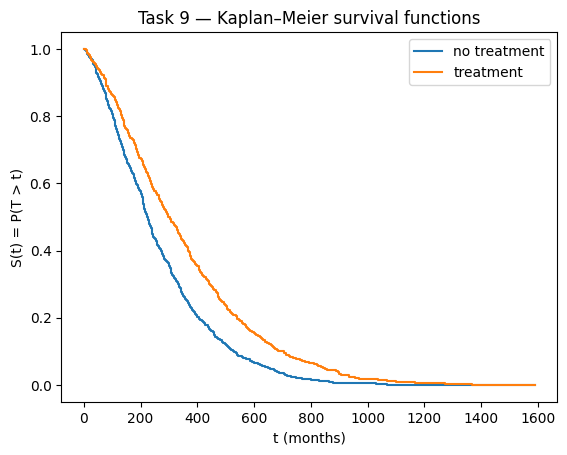

Mean lifetime  no treatment : 264.6 months
Mean lifetime  treatment    : 350.1 months


In [18]:
# Build treatment Q; fill diagonals so rows sum to 0
Q_treat = np.array([
    [0.0,     0.0025, 0.00125, 0.0,   0.001],
    [0.0,     0.0,    0.0,     0.002, 0.005],
    [0.0,     0.0,    0.0,     0.003, 0.005],
    [0.0,     0.0,    0.0,     0.0,   0.009],
    [0.0,     0.0,    0.0,     0.0,   0.0],
])
for i in range(4):
    Q_treat[i, i] = -Q_treat[i].sum()
print("Treatment Q row sums:", np.round(Q_treat.sum(axis=1), 12))

rng = np.random.default_rng(1)
life_treat = np.array([simulate_ctmc(Q_treat, rng)[0] for _ in range(N)])

def kaplan_meier(times, grid):
    n = len(times)
    return np.array([(times > t).sum() / n for t in grid])

grid = np.linspace(0, max(life_ct.max(), life_treat.max()), 500)
plt.step(grid, kaplan_meier(life_ct, grid), where='post', label='no treatment')
plt.step(grid, kaplan_meier(life_treat, grid), where='post', label='treatment')
plt.xlabel('t (months)'); plt.ylabel('S(t) = P(T > t)')
plt.title('Task 9 — Kaplan–Meier survival functions')
plt.legend(); plt.show()
print(f"Mean lifetime  no treatment : {life_ct.mean():.1f} months")
print(f"Mean lifetime  treatment    : {life_treat.mean():.1f} months")

## Part 3 — Estimation

In practice $Q$ is unknown and the state is only observed every 48 months
(every 4th year). We first generate such sparse observations (Task 12), then
recover $Q$ with a Monte-Carlo Expectation–Maximisation algorithm (Task 13).

### Task 12 --- Generate observed time series every 48 months


Example observed series: [[0, 0, 0, 4], [0, 4], [0, 1, 1, 1, 3, 4]]
Mean series length: 7.02


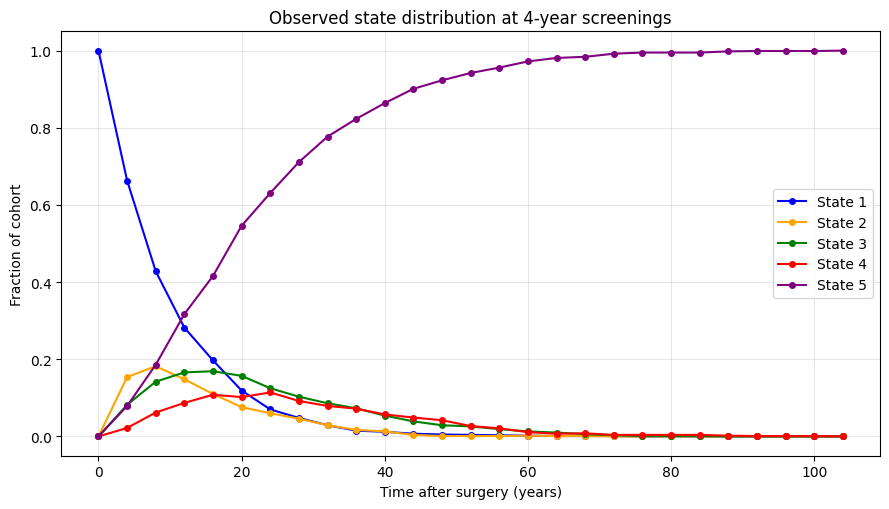

In [20]:
DT_OBS = 48
def observe_series(Q, rng, dt=DT_OBS, start=0):
    """Observe one woman's state every `dt` months until death."""
    lt, traj = simulate_ctmc(Q, rng, start)
    n_obs = int(np.ceil(lt / dt))
    ys = [state_at_time(traj, k * dt) for k in range(n_obs)]
    ys.append(4)             # death is observed as the final value
    return ys

rng = np.random.default_rng(1)
series = [observe_series(Q, rng) for _ in range(1000)]
print("Example observed series:", series[:3])
print(f"Mean series length: {np.mean([len(s) for s in series]):.2f}")

# ----------------------- State distribution over time (death carried forward) -----------------------
# Once a woman dies she stays counted in state 5 at every later screening, so the
# five fractions sum to one at every screening and state 5 accumulates toward 1
# (it equals the cumulative fraction dead, i.e. 1 - S(t)).
N = len(series)
max_k = max(len(s) for s in series)
prop = np.zeros((5, max_k))
for ys in series:
    for k in range(max_k):
        st = ys[k] if k < len(ys) else 4    # after the series ends, remain dead
        prop[st, k] += 1
prop /= N                                    # fraction of the full cohort
years = np.arange(max_k) * DT_OBS / 12.0

colors = ["blue", "orange","green","red", "purple"]
fig, ax = plt.subplots(figsize=(9, 5.2))
for s in range(5):
    ax.plot(years, prop[s], marker='o', ms=4, color=colors[s], label=f'State {s+1}')
ax.set_xlabel('Time after surgery (years)')
ax.set_ylabel('Fraction of cohort')
ax.set_title('Observed state distribution at 4-year screenings')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 13

In [21]:
def simulate_bridge(Qk, rng, a, b, T, max_tries=5000):
    """Rejection-sample a CTMC path on [0,T] with X(0)=a, X(T)=b.
    Returns list of (sojourn_duration, state) covering [0,T]."""
    for _ in range(max_tries):
        s = a; t = 0.0; segs = []
        ok = True
        while True:
            rate = -Qk[s, s]
            if rate <= 0:                      # absorbing state reached
                segs.append((T - t, s))
                ok = (s == b)
                break
            dt = rng.exponential(1.0 / rate)
            if t + dt >= T:
                segs.append((T - t, s))        # stays in s until T
                ok = (s == b)
                break
            segs.append((dt, s)); t += dt
            probs = Qk[s].copy(); probs[s] = 0.0; probs /= probs.sum()
            s = rng.choice(5, p=probs)
        if ok:
            return segs
    return None

def mcem(series, Q0, rng, tol=1e-3, max_iter=50, dt=DT_OBS,
         stop_on_tol=True, verbose=True):
    """Monte-Carlo EM for the rate matrix. Returns (Q_hat, history) where
    history[k] = ||Q^{(k)} - Q^{(k-1)}||_inf, the sup-norm change at iteration k."""
    Qk = Q0.copy()
    history = []
    for it in range(max_iter):
        Nij = np.zeros((5, 5)); Si = np.zeros(5)
        for ys in series:
            for k in range(len(ys) - 1):
                a, b = ys[k], ys[k + 1]
                if a == 4:
                    break
                seg = None
                while seg is None:
                    seg = simulate_bridge(Qk, rng, a, b, dt)
                for idx, (dur, st) in enumerate(seg):
                    Si[st] += dur
                    if idx < len(seg) - 1:
                        Nij[st, seg[idx + 1][1]] += 1
        Qnew = np.zeros((5, 5))
        for i in range(4):
            for j in range(5):
                if i != j and Si[i] > 0:
                    Qnew[i, j] = Nij[i, j] / Si[i]
            Qnew[i, i] = -Qnew[i].sum()
        diff = np.abs(Qk - Qnew).max()
        history.append(diff)
        Qk = Qnew
        if verbose:
            print(f"iter {it:2d}  ||.||_inf = {diff:.5e}")
        if stop_on_tol and diff < tol:
            break
    return Qk, history

Q0 = np.array([
    [-0.02, 0.010, 0.005, 0.000, 0.005],
    [ 0.00,-0.020, 0.007, 0.007, 0.006],
    [ 0.00, 0.000,-0.010, 0.005, 0.005],
    [ 0.00, 0.000, 0.000,-0.010, 0.010],
    [ 0.00, 0.000, 0.000, 0.000, 0.000],
])

# Run a fixed number of MCEM iterations.
rng = np.random.default_rng(1)
Q_hat, history = mcem(series, Q0, rng, max_iter=2, stop_on_tol=False)

np.set_printoptions(precision=5, suppress=True)
print("\nEstimated Q:\n", Q_hat)
print("\nTrue Q:\n", Q)
print("\nAbsolute-difference matrix |Q_hat - Q|:\n", np.abs(Q_hat - Q))
print("\nMax abs error:", np.abs(Q_hat - Q).max())

iter  0  ||.||_inf = 1.10740e-02
iter  1  ||.||_inf = 4.52867e-04

Estimated Q:
 [[-0.00888  0.00523  0.00232  0.       0.00133]
 [ 0.      -0.01412  0.00551  0.004    0.0046 ]
 [ 0.       0.      -0.00775  0.00373  0.00403]
 [ 0.       0.       0.      -0.0086   0.0086 ]
 [ 0.       0.       0.       0.       0.     ]]

True Q:
 [[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]

Absolute-difference matrix |Q_hat - Q|:
 [[0.00038 0.00023 0.00018 0.      0.00033]
 [0.      0.00012 0.00051 0.      0.0004 ]
 [0.      0.      0.00025 0.00073 0.00097]
 [0.      0.      0.      0.0004  0.0004 ]
 [0.      0.      0.      0.      0.     ]]

Max abs error: 0.0009739009190665414


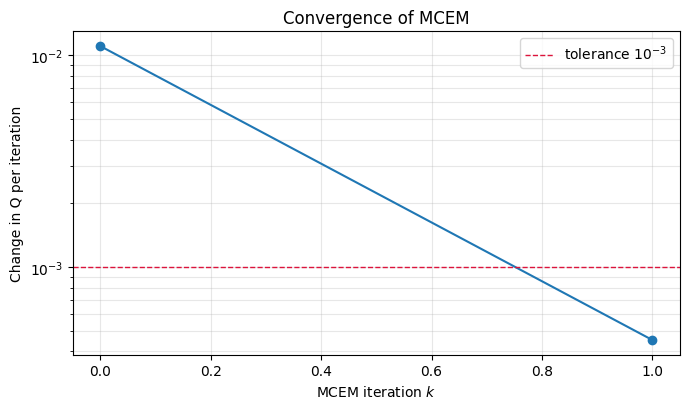

In [22]:
# Convergence of the MCEM: sup-norm change per iteration (log scale)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(range(len(history)), history, marker='o', color='#1f77b4')
ax.axhline(1e-3, color='crimson', ls='--', lw=1, label=r'tolerance $10^{-3}$')
ax.set_yscale('log')
ax.set_xlabel('MCEM iteration $k$')
ax.set_ylabel('Change in Q per iteration')
ax.set_title('Convergence of MCEM')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()